# Proiect: Reprezentarea grafică a unei funcții matematice

Acest notebook permite alegerea unei funcții, citirea coeficienților de la tastatură, calculul valorilor $f(x)$ și afișarea graficului folosind `numpy` și `matplotlib`.

Alege tipul funcției:
1 - funcție de gradul 2: f(x) = a*x^2 + b*x + c
2 - funcție liniară: f(x) = a*x + b
3 - funcție exponențială: f(x) = a * e^(b*x)
4 - funcție radical: f(x) = sqrt(a*x + b)

Ai ales: funcție de gradul 2
Forma generală: f(x) = a*x^2 + b*x + c
Semnificația coeficienților:
- a: coeficient principal (controlează panta/curbura/scara)
- b: coeficient secundar (deplasare sau ritm de creștere/scădere)
- c: termen liber (intersecția cu Oy pentru funcția de gradul 2)


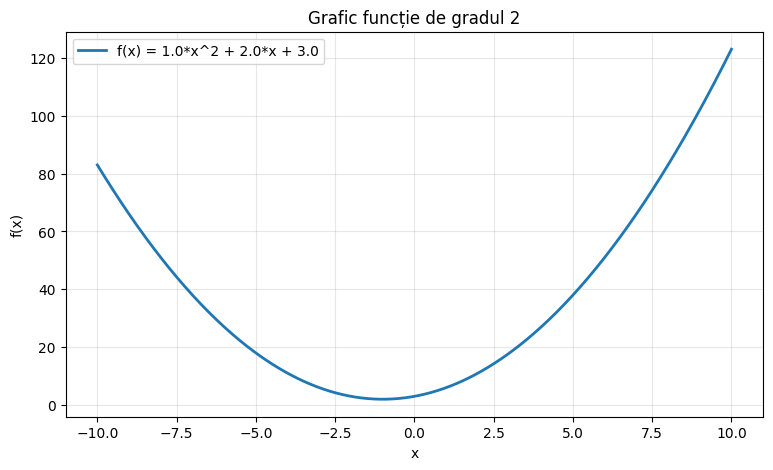

In [2]:
# Importăm bibliotecile necesare
import numpy as np
import matplotlib.pyplot as plt

# Definim informații despre funcțiile disponibile
functii = {
    "1": {
        "nume": "funcție de gradul 2",
        "forma": "f(x) = a*x^2 + b*x + c",
        "coef": "a, b, c"
    },
    "2": {
        "nume": "funcție liniară",
        "forma": "f(x) = a*x + b",
        "coef": "a, b"
    },
    "3": {
        "nume": "funcție exponențială",
        "forma": "f(x) = a * e^(b*x)",
        "coef": "a, b"
    },
    "4": {
        "nume": "funcție radical",
        "forma": "f(x) = sqrt(a*x + b)",
        "coef": "a, b"
    }
}

# Afișăm opțiunile
print("Alege tipul funcției:")
print("1 - funcție de gradul 2: f(x) = a*x^2 + b*x + c")
print("2 - funcție liniară: f(x) = a*x + b")
print("3 - funcție exponențială: f(x) = a * e^(b*x)")
print("4 - funcție radical: f(x) = sqrt(a*x + b)")

optiune = input("Introdu opțiunea (1/2/3/4): ").strip()
if optiune not in functii:
    raise ValueError("Opțiune invalidă. Repornește celula și alege 1, 2, 3 sau 4.")

# Afișăm forma generală și explicația coeficienților
info = functii[optiune]
print("\nAi ales:", info["nume"])
print("Forma generală:", info["forma"])
print("Semnificația coeficienților:")
print("- a: coeficient principal (controlează panta/curbura/scara)")
print("- b: coeficient secundar (deplasare sau ritm de creștere/scădere)")
print("- c: termen liber (intersecția cu Oy pentru funcția de gradul 2)")

# Citim coeficienții (dacă apeși Enter, folosim valori implicite)
a_text = input("Introdu a (implicit 1): " ).strip()
b_text = input("Introdu b (implicit 0): " ).strip()
a = float(a_text) if a_text else 1.0
b = float(b_text) if b_text else 0.0
c = None
if optiune == "1":
    c_text = input("Introdu c (implicit 0): " ).strip()
    c = float(c_text) if c_text else 0.0

# Construim vectorul de valori x
x = np.linspace(-10, 10, 400)

# Calculăm valorile f(x) și formula pentru legendă
if optiune == "1":
    y = a * x**2 + b * x + c
    formula = f"f(x) = {a}*x^2 + {b}*x + {c}"
    titlu = "Grafic funcție de gradul 2"
elif optiune == "2":
    y = a * x + b
    formula = f"f(x) = {a}*x + {b}"
    titlu = "Grafic funcție liniară"
elif optiune == "3":
    y = a * np.exp(b * x)
    formula = f"f(x) = {a} * e^({b}*x)"
    titlu = "Grafic funcție exponențială"
else:
    # Pentru radical păstrăm doar valorile cu ax+b >= 0
    masca = a * x + b >= 0
    x = x[masca]
    if len(x) == 0:
        raise ValueError("Nu există puncte în domeniul real pentru intervalul ales.")
    y = np.sqrt(a * x + b)
    formula = f"f(x) = sqrt({a}*x + {b})"
    titlu = "Grafic funcție radical"

# Afișăm graficul
plt.figure(figsize=(9, 5))
plt.plot(x, y, label=formula, color="tab:blue", linewidth=2)
plt.xlabel("x")
plt.ylabel("f(x)")
plt.title(titlu)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## Cum rulezi
1. Rulează celula de cod.
2. Alege tipul funcției și introdu coeficienții ceruți.
3. Vei vedea forma funcției, explicația coeficienților și graficul final în output-ul notebook-ului.

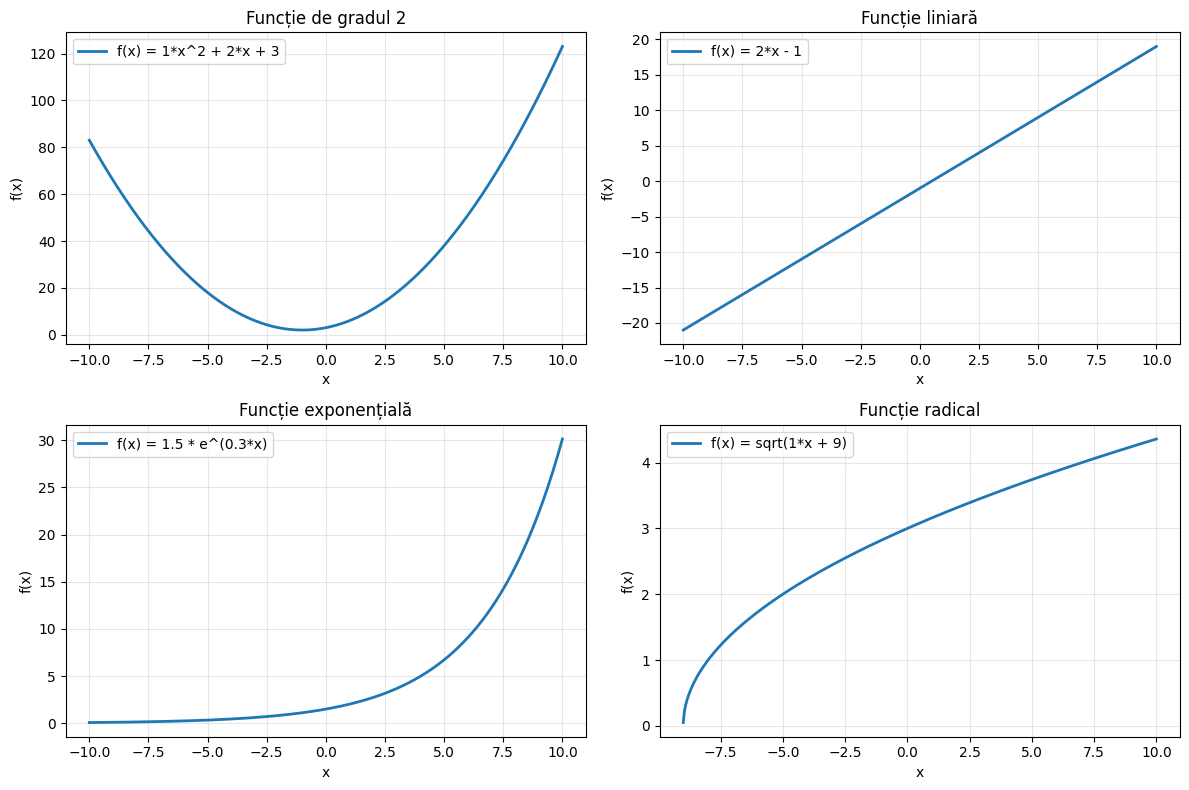

In [3]:
# Demo automat: rulăm toate cele 4 tipuri de funcții cu coeficienți exemplu
import numpy as np
import matplotlib.pyplot as plt

x_full = np.linspace(-10, 10, 400)

exemple = [
    {
        "titlu": "Funcție de gradul 2",
        "formula": "f(x) = 1*x^2 + 2*x + 3",
        "x": x_full,
        "y": 1 * x_full**2 + 2 * x_full + 3,
    },
    {
        "titlu": "Funcție liniară",
        "formula": "f(x) = 2*x - 1",
        "x": x_full,
        "y": 2 * x_full - 1,
    },
    {
        "titlu": "Funcție exponențială",
        "formula": "f(x) = 1.5 * e^(0.3*x)",
        "x": x_full,
        "y": 1.5 * np.exp(0.3 * x_full),
    },
    {
        "titlu": "Funcție radical",
        "formula": "f(x) = sqrt(1*x + 9)",
        "x": x_full[x_full >= -9],
        "y": np.sqrt(x_full[x_full >= -9] + 9),
    },
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, item in zip(axes, exemple):
    ax.plot(item["x"], item["y"], linewidth=2, label=item["formula"])
    ax.set_title(item["titlu"])
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()